In [1]:
# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os 
os.listdir()

['instructor_effectiveness.ipynb']

In [3]:
df = pd.read_excel("../data/data.xlsx")

In [4]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [5]:
df.shape

(2000, 12)

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   str    
 1   instructor_id               2000 non-null   str    
 2   course_id                   2000 non-null   str    
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), str(3)
memory usage: 216.9 KB


In [7]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489260,0.603091,0.712797,0.980000
avg_score_improvement,2000.0,27.035844,5.716641,6.159240,23.124673,26.938629,30.885600,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


In [9]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

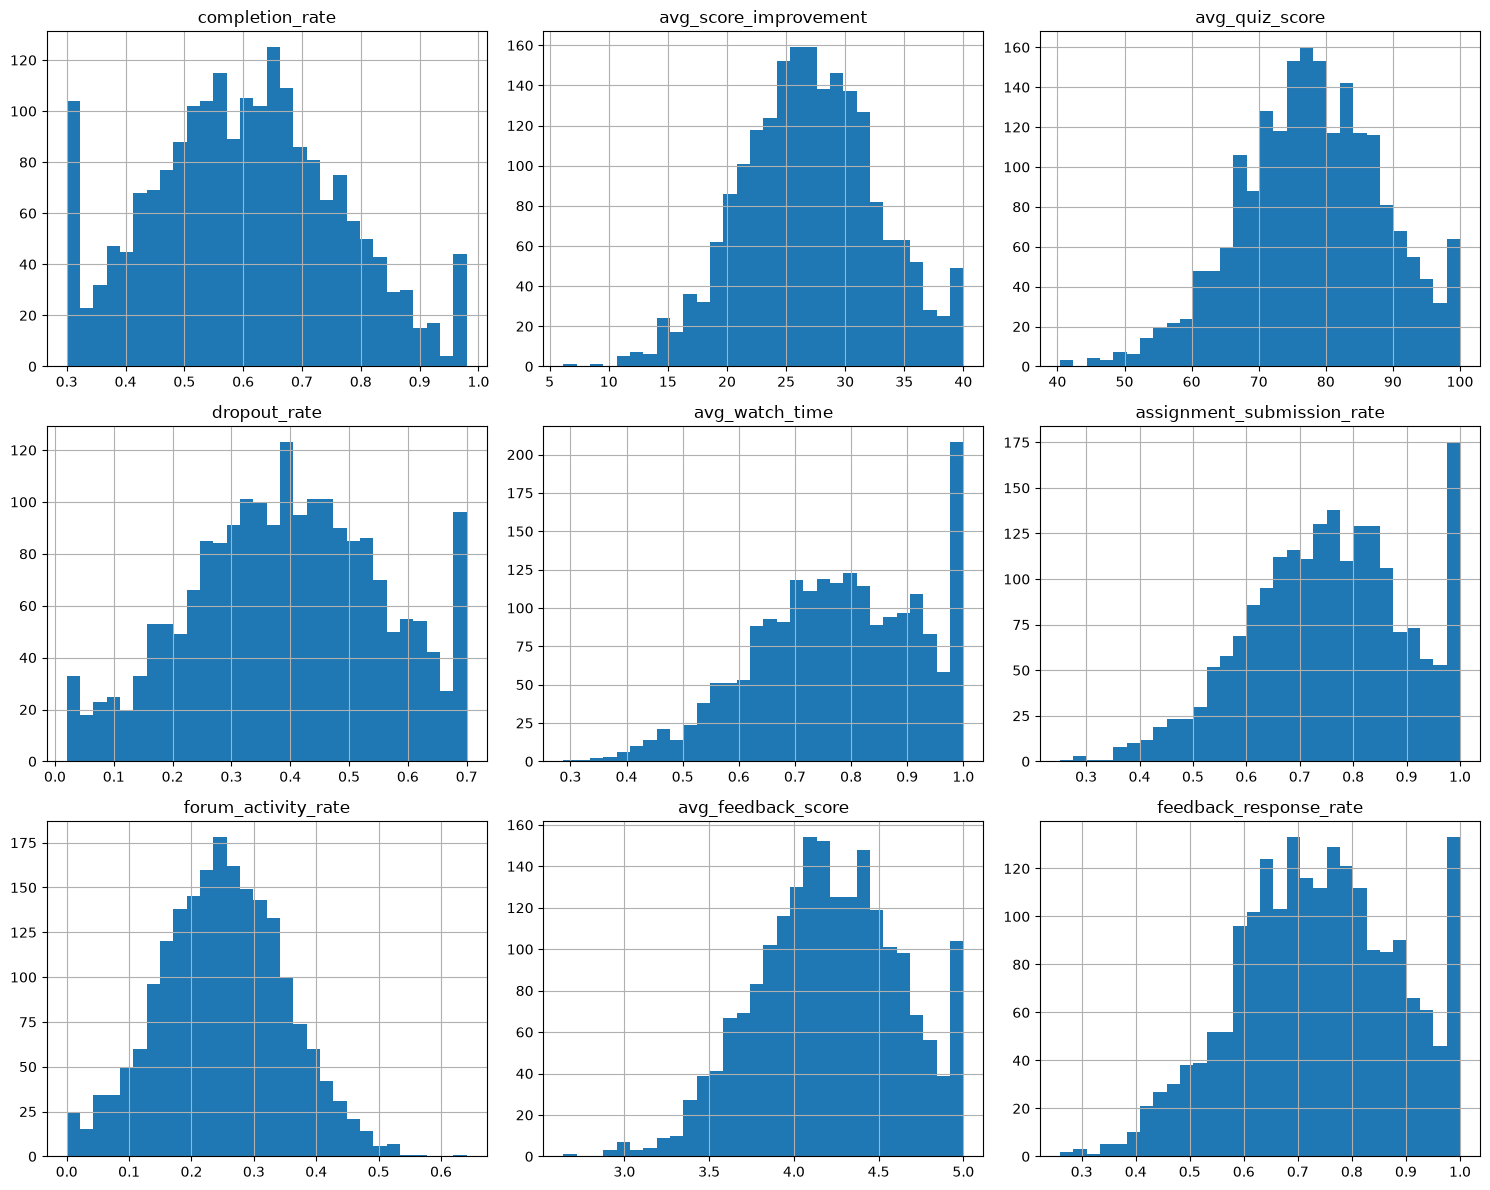

In [11]:
# Distribution of numerical features

df.hist(figsize=(15, 12), bins=30)

plt.tight_layout()
plt.show()

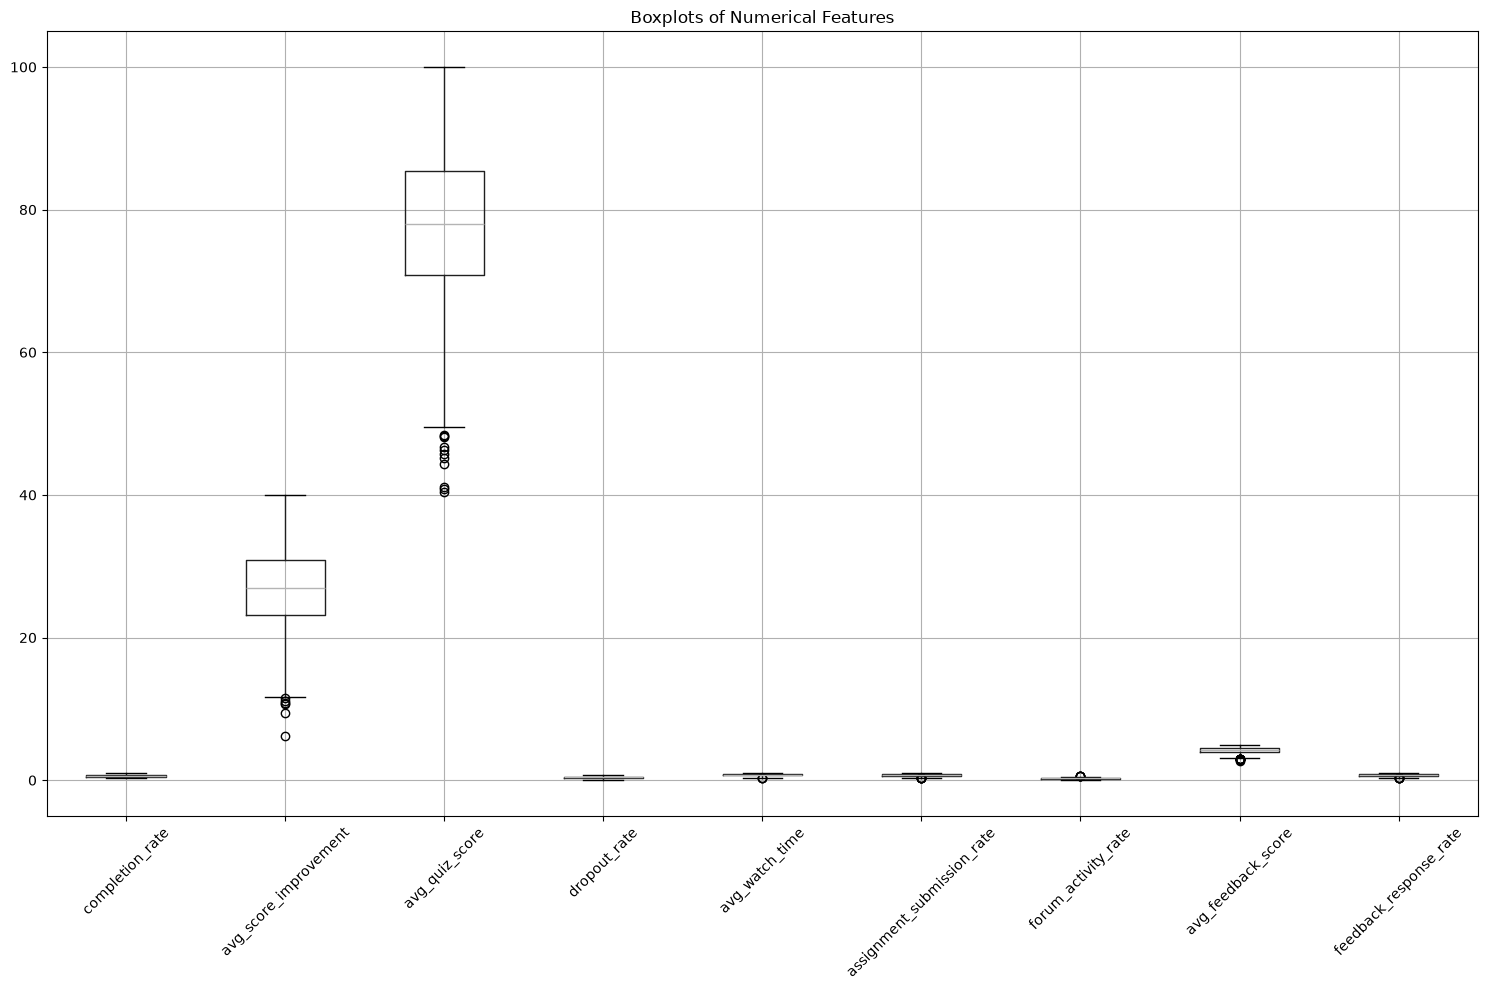

In [14]:
# Outlier analysis using boxplots

plt.figure(figsize=(15,10))

df.boxplot(
    column=[
        'completion_rate',
        'avg_score_improvement',
        'avg_quiz_score',
        'dropout_rate',
        'avg_watch_time',
        'assignment_submission_rate',
        'forum_activity_rate',
        'avg_feedback_score',
        'feedback_response_rate'
    ]
)

plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.tight_layout()
plt.show()

<Axes: >

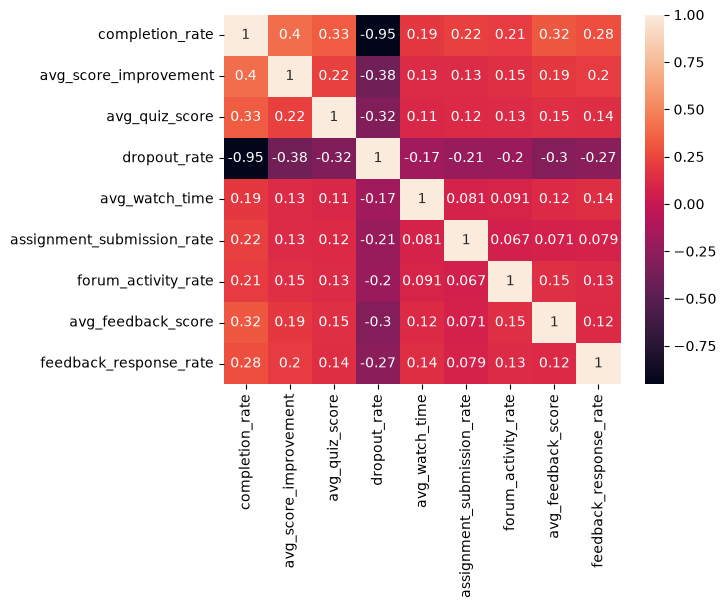

In [15]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [27]:
from sklearn.preprocessing import MinMaxScaler

# columns for each group
learning_cols = ['completion_rate', 'dropout_rate', 'avg_score_improvement', 'avg_quiz_score']
engagement_cols = ['avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate']
feedback_cols = ['avg_feedback_score', 'feedback_response_rate']

# min-max scale all metrics to 0-1
scaler = MinMaxScaler()
scaled = df.copy()
all_cols = learning_cols + engagement_cols + feedback_cols
scaled[all_cols] = scaler.fit_transform(df[all_cols])

# invert dropout_rate since higher dropout = worse effectiveness
scaled['dropout_rate'] = 1 - scaled['dropout_rate']

# combine within each group (row-wise mean)
learning_score = scaled[learning_cols].mean(axis=1)
engagement_score = scaled[engagement_cols].mean(axis=1)
feedback_score = scaled[feedback_cols].mean(axis=1)

# weighted sum -> final effectiveness score
df['effectiveness_score'] = (
    0.5 * learning_score +
    0.3 * engagement_score +
    0.2 * feedback_score
)

# convert to tiers using quantiles
df['effectiveness_tier'] = pd.qcut(
    df['effectiveness_score'], q=3, labels=['Low', 'Medium', 'High']
)

df[['effectiveness_score', 'effectiveness_tier']].head()

,effectiveness_score,effectiveness_tier
0,0.450380,Medium
1,0.682006,High
2,0.707803,High
3,0.388822,Low
4,0.802542,High


In [28]:
df['effectiveness_tier'].value_counts()

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

In [29]:
df['effectiveness_score'].describe()

count    120.000000
mean       0.503702
std        0.172225
min        0.071751
25%        0.400479
50%        0.506549
75%        0.601459
max        0.963299
Name: effectiveness_score, dtype: float64

In [30]:
df['instructor_id'].nunique()
df

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,num_batches,effectiveness_score,effectiveness_tier
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,25,0.450380,Medium
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,20,0.682006,High
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,18,0.707803,High
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,17,0.388822,Low
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,19,0.802542,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,I_116,0.597106,0.412782,26.029714,78.640236,0.761489,0.660695,0.274891,4.091469,0.719787,17,0.457286,Medium
116,I_117,0.691715,0.312481,28.430884,80.981607,0.793272,0.814243,0.265179,4.305839,0.713759,19,0.598098,High
117,I_118,0.820753,0.202034,32.636791,87.071798,0.773422,0.829285,0.258419,4.641986,0.868611,19,0.787692,High
118,I_119,0.600597,0.399761,25.159349,80.735733,0.774830,0.766803,0.227028,4.315403,0.759761,19,0.513314,Medium


In [24]:
df = df.groupby('instructor_id').agg({
    'completion_rate': 'mean',
    'dropout_rate': 'mean',
    'avg_score_improvement': 'mean',
    'avg_quiz_score': 'mean',
    'avg_watch_time': 'mean',
    'assignment_submission_rate': 'mean',
    'forum_activity_rate': 'mean',
    'avg_feedback_score': 'mean',
    'feedback_response_rate': 'mean',
    'batch_id': 'count'   # gives you number of batches per instructor
}).rename(columns={'batch_id': 'num_batches'})

df = df.reset_index()
df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,num_batches
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,25
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,20
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,18
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,17
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,19


In [25]:
df.shape

(120, 11)

In [26]:
df['num_batches'].describe()

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
Name: num_batches, dtype: float64

In [31]:
df

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,num_batches,effectiveness_score,effectiveness_tier
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,25,0.450380,Medium
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,20,0.682006,High
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,18,0.707803,High
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,17,0.388822,Low
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,19,0.802542,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,I_116,0.597106,0.412782,26.029714,78.640236,0.761489,0.660695,0.274891,4.091469,0.719787,17,0.457286,Medium
116,I_117,0.691715,0.312481,28.430884,80.981607,0.793272,0.814243,0.265179,4.305839,0.713759,19,0.598098,High
117,I_118,0.820753,0.202034,32.636791,87.071798,0.773422,0.829285,0.258419,4.641986,0.868611,19,0.787692,High
118,I_119,0.600597,0.399761,25.159349,80.735733,0.774830,0.766803,0.227028,4.315403,0.759761,19,0.513314,Medium


In [32]:
from sklearn.preprocessing import MinMaxScaler

learning_cols = ['completion_rate', 'dropout_rate', 'avg_score_improvement', 'avg_quiz_score']
engagement_cols = ['avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate']
feedback_cols = ['avg_feedback_score', 'feedback_response_rate']

scaler = MinMaxScaler()
scaled = df.copy()
all_cols = learning_cols + engagement_cols + feedback_cols
scaled[all_cols] = scaler.fit_transform(df[all_cols])

# invert dropout_rate (higher dropout = worse)
scaled['dropout_rate'] = 1 - scaled['dropout_rate']

learning_score = scaled[learning_cols].mean(axis=1)
engagement_score = scaled[engagement_cols].mean(axis=1)
feedback_score = scaled[feedback_cols].mean(axis=1)

df['effectiveness_score'] = (
    0.5 * learning_score +
    0.3 * engagement_score +
    0.2 * feedback_score
)

df['effectiveness_tier'] = pd.qcut(
    df['effectiveness_score'], q=3, labels=['Low', 'Medium', 'High']
)

df[['instructor_id', 'effectiveness_score', 'effectiveness_tier']].head()

,instructor_id,effectiveness_score,effectiveness_tier
0,I_001,0.450380,Medium
1,I_002,0.682006,High
2,I_003,0.707803,High
3,I_004,0.388822,Low
4,I_005,0.802542,High


In [33]:
df['effectiveness_tier'].value_counts()

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

In [34]:
df

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,num_batches,effectiveness_score,effectiveness_tier
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,25,0.450380,Medium
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,20,0.682006,High
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,18,0.707803,High
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,17,0.388822,Low
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,19,0.802542,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,I_116,0.597106,0.412782,26.029714,78.640236,0.761489,0.660695,0.274891,4.091469,0.719787,17,0.457286,Medium
116,I_117,0.691715,0.312481,28.430884,80.981607,0.793272,0.814243,0.265179,4.305839,0.713759,19,0.598098,High
117,I_118,0.820753,0.202034,32.636791,87.071798,0.773422,0.829285,0.258419,4.641986,0.868611,19,0.787692,High
118,I_119,0.600597,0.399761,25.159349,80.735733,0.774830,0.766803,0.227028,4.315403,0.759761,19,0.513314,Medium


In [41]:
#Model Building
# I considered both Logisstic regression and random forest classifier and finalizing by analyzing accuracies
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

feature_cols = ['completion_rate', 'dropout_rate', 'avg_score_improvement', 'avg_quiz_score',
                'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
                'avg_feedback_score', 'feedback_response_rate']

X = df[feature_cols]
y = df['effectiveness_tier']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression needs scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# Random Forest doesn't need scaling
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
Accuracy: 0.875
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      0.75      0.86         8
      Medium       0.73      1.00      0.84         8

    accuracy                           0.88        24
   macro avg       0.91      0.88      0.88        24
weighted avg       0.91      0.88      0.88        24

=== Random Forest ===
Accuracy: 0.9166666666666666
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      0.88      0.93         8
      Medium       0.80      1.00      0.89         8

    accuracy                           0.92        24
   macro avg       0.93      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24



In [39]:
print(confusion_matrix(y_test, y_pred_rf, labels=['Low', 'Medium', 'High']))

[[7 1 0]
 [0 8 0]
 [0 1 7]]


In [37]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

completion_rate               0.244481
dropout_rate                  0.232007
feedback_response_rate        0.161619
avg_score_improvement         0.135529
avg_quiz_score                0.069206
avg_feedback_score            0.053309
forum_activity_rate           0.041621
avg_watch_time                0.039578
assignment_submission_rate    0.022649
dtype: float64


<Axes: >

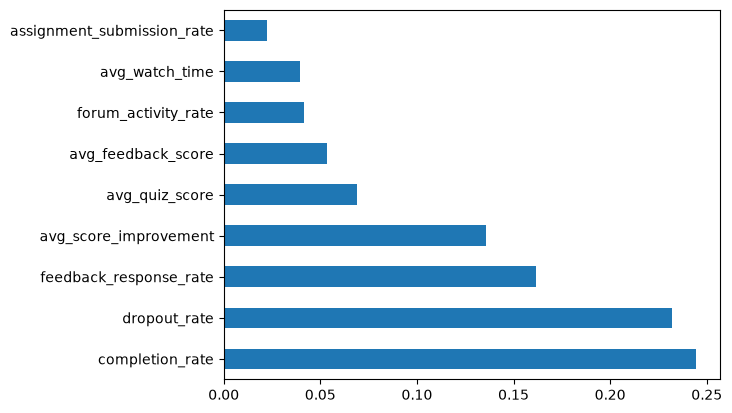

In [38]:
importances.plot(kind='barh')